In [16]:
import sys
sys.path.append('../..')

from src import utils
import src.channelCoding as cc
from pymongo import MongoClient
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# MongoDB connection


clients = MongoClient('mongodb://localhost:27017/')
dbs = []
for db in clients.list_database_names():
    if db.startswith('r0_r1_SC_alpha'):
        dbs.append(clients[db]['destination, phase_1'])

In [ ]:
dbs

[Collection(Database(MongoClient(host=['localhost:27017'], document_class=dict, tz_aware=False, connect=True), 'r0_r1_SC_alpha_0_15_R=0_5'), 'destination, phase_1'),
 Collection(Database(MongoClient(host=['localhost:27017'], document_class=dict, tz_aware=False, connect=True), 'r0_r1_SC_alpha_0_1_R=0_5'), 'destination, phase_1'),
 Collection(Database(MongoClient(host=['localhost:27017'], document_class=dict, tz_aware=False, connect=True), 'r0_r1_SC_alpha_0_25_R=0_5'), 'destination, phase_1'),
 Collection(Database(MongoClient(host=['localhost:27017'], document_class=dict, tz_aware=False, connect=True), 'r0_r1_SC_alpha_0_2_R=0_5'), 'destination, phase_1'),
 Collection(Database(MongoClient(host=['localhost:27017'], document_class=dict, tz_aware=False, connect=True), 'r0_r1_SC_alpha_0_35_R=0_5'), 'destination, phase_1'),
 Collection(Database(MongoClient(host=['localhost:27017'], document_class=dict, tz_aware=False, connect=True), 'r0_r1_SC_alpha_0_3_R=0_5'), 'destination, phase_1'),
 Collec

In [21]:
pd.DataFrame(list(dbs[0].find({})))

,_id,BER_tag,BER_msg,r0,r1,SNR,sigma_n2,config
0,6894fae435183f9455c80198,0.415776,0.112870,"[0.0035002999506680574, 1.608149210198656e-05,...","[0.00011501964092315682, 0.0017967992979043698...",3.479410,1.135969e-07,"{'_id': 687ebcefbe94ff982757e758, 'MongoDB_Col..."
1,6894fae835183f9455c8019a,0.409882,0.118284,"[0.020515778419189758, 6.063725933310875e-05, ...","[0.007999962239559923, 0.0004983216484357129, ...",3.353220,1.135997e-07,"{'_id': 687ebcefbe94ff982757e758, 'MongoDB_Col..."
2,6894faf835183f9455c8019e,0.412623,0.115611,"[0.002890010292392732, 0.0004200082488713003, ...","[0.000321349721079031, 0.001360360918212201, 0...",3.516576,1.122915e-07,"{'_id': 687ebcefbe94ff982757e758, 'MongoDB_Col..."
3,6894fafc35183f9455c801a0,0.407758,0.118764,"[0.0016537297378702305, 0.00024151345022659155...","[0.0006575901646520354, 0.0015212043221508344,...",3.445645,1.122834e-07,"{'_id': 687ebcefbe94ff982757e758, 'MongoDB_Col..."
4,6894fb0c35183f9455c801a4,0.408512,0.116982,"[0.000910318762541555, 0.0004458230320787859, ...","[6.460786267658703e-05, 0.0010863399173612583,...",3.506718,1.127338e-07,"{'_id': 687ebcefbe94ff982757e758, 'MongoDB_Col..."
...,...,...,...,...,...,...,...,...
185,689501f735183f9455c803c1,0.271998,0.014460,"[0.031592921600189415, 0.0018875776522153532, ...","[0.010768851439966825, 0.0019305303876448964, ...",7.648416,1.174392e-07,"{'_id': 687ebcefbe94ff982757e758, 'MongoDB_Col..."
186,6895020735183f9455c803c5,0.288240,0.013089,"[0.006307436173129655, 0.0005379341348674421, ...","[0.00023515711332320723, 0.0028544109971729093...",7.716480,1.137983e-07,"{'_id': 687ebcefbe94ff982757e758, 'MongoDB_Col..."
187,6895020b35183f9455c803c7,0.280291,0.011308,"[0.008647751885163245, 0.0008698502000535333, ...","[0.00022581401427390917, 0.002487687967169388,...",7.721931,1.137904e-07,"{'_id': 687ebcefbe94ff982757e758, 'MongoDB_Col..."
188,6895021b35183f9455c803cb,0.282689,0.013021,"[0.008033294330785524, 0.0006914176743864176, ...","[0.00011891775762321482, 0.003647722947738715,...",7.749732,1.129613e-07,"{'_id': 687ebcefbe94ff982757e758, 'MongoDB_Col..."


/tmp/ipykernel_1858569/3462074254.py:74: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  msg_cmap = mpl.cm.get_cmap(msg_cmap_name)
/tmp/ipykernel_1858569/3462074254.py:75: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  tag_cmap = mpl.cm.get_cmap(tag_cmap_name)


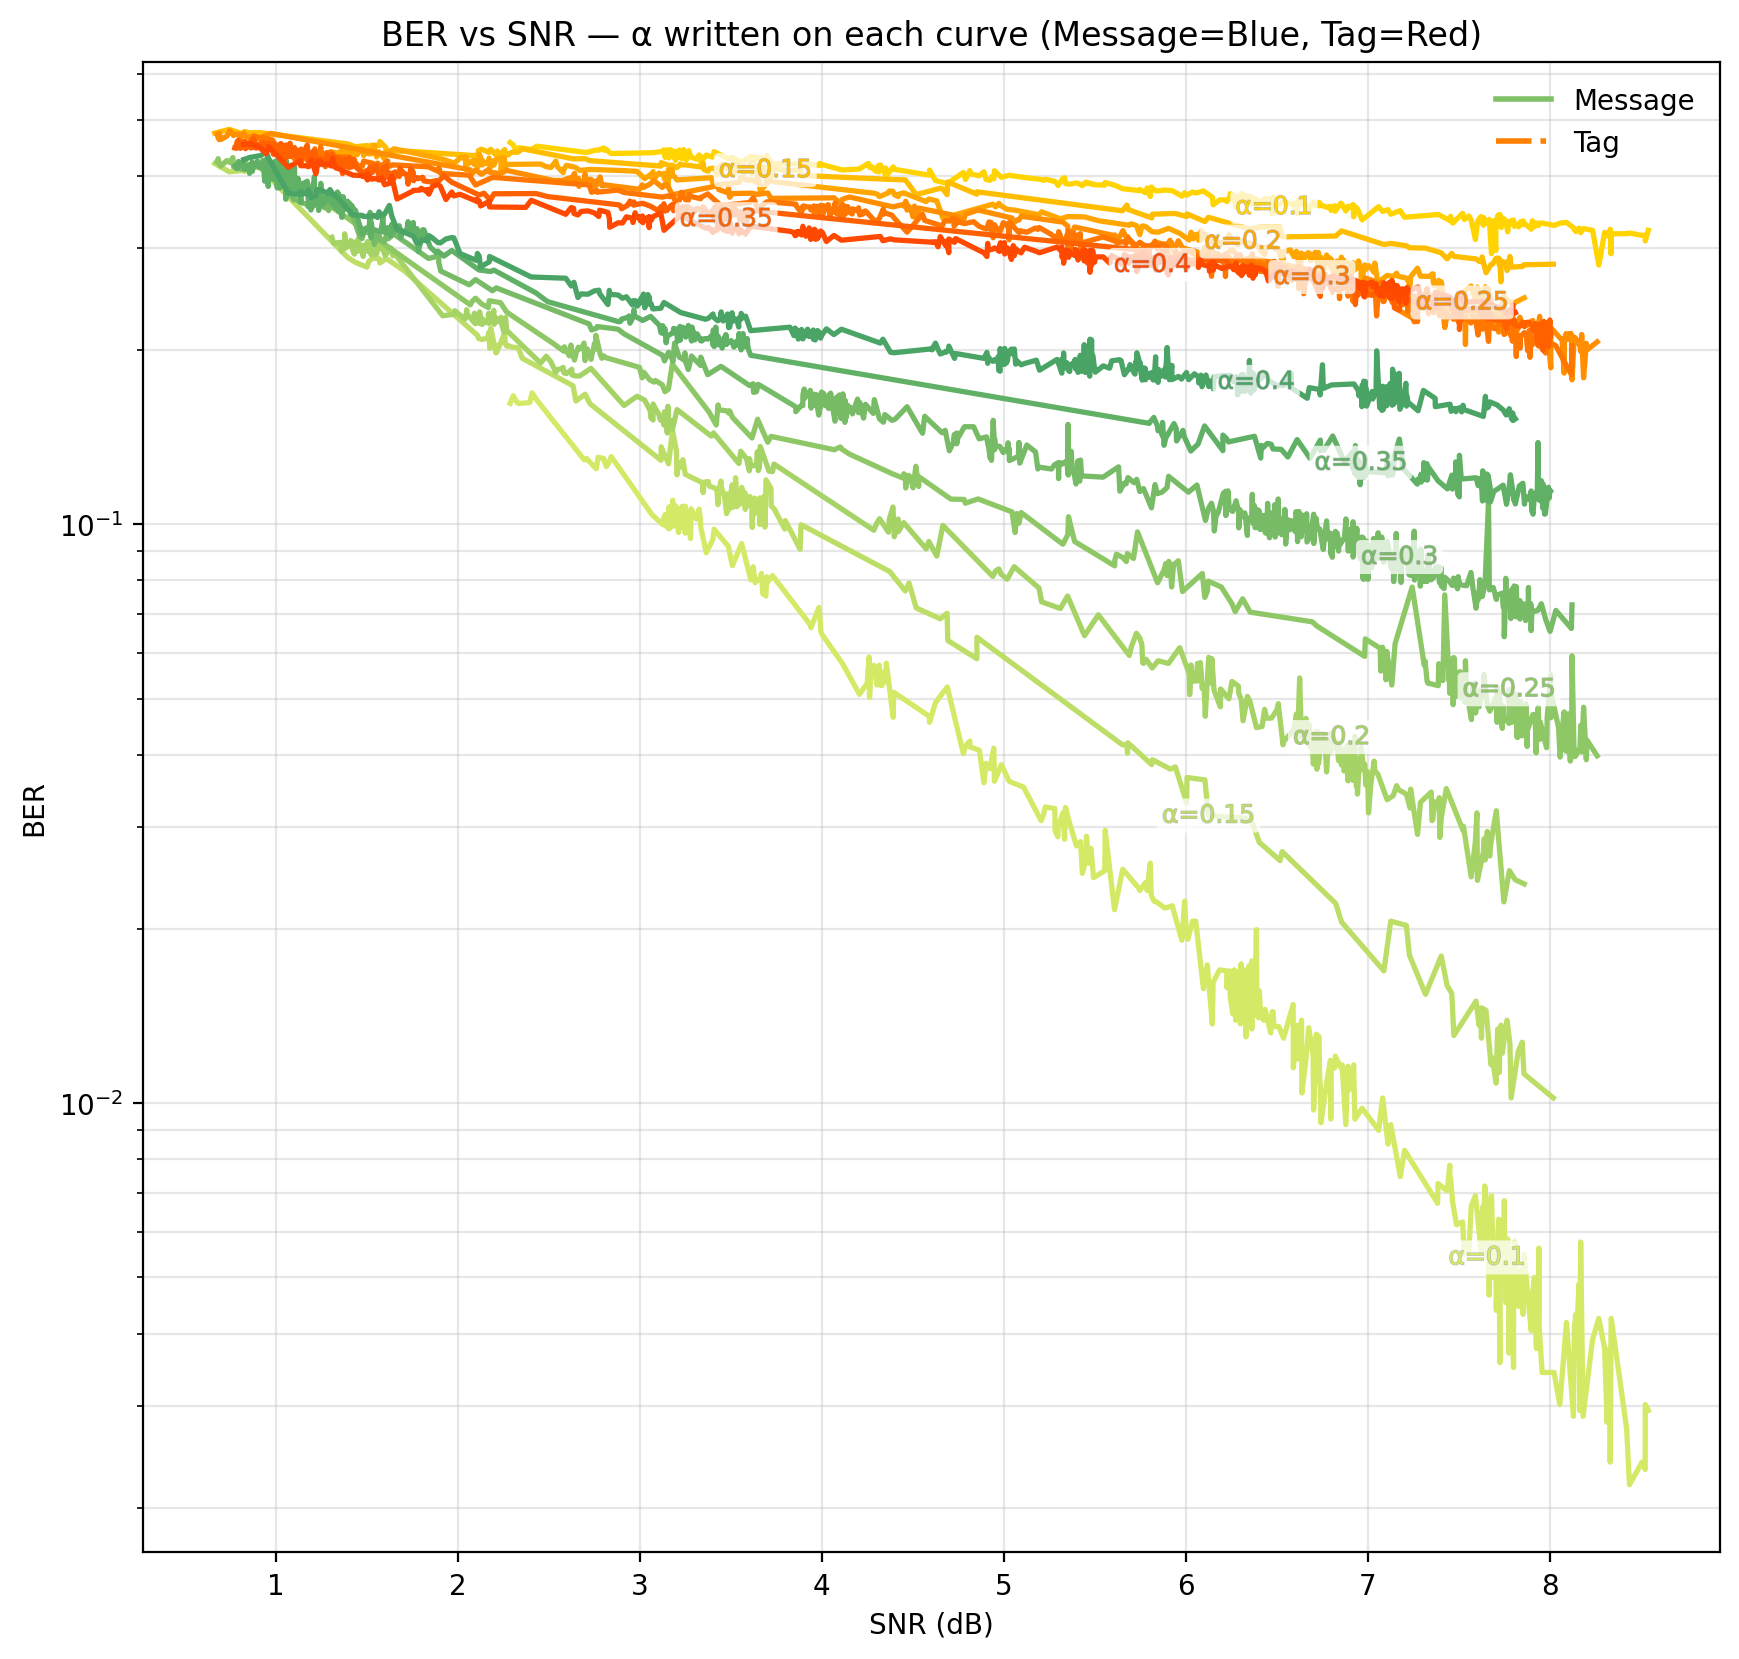

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patheffects as pe

# --- alpha from your docs ---------------------------------------------------
def infer_alpha(coll):
    return float(coll.find_one({})["config"]["ALPHA"])

# --- helpers ----------------------------------------------------------------
def df_from_collection(coll):
    cur = coll.find({}, {"BER_tag": 1, "BER_msg": 1, "SNR": 1, "_id": 0})
    df = pd.DataFrame(list(cur))
    if df.empty:
        return df
    for c in ["BER_tag", "BER_msg", "SNR"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.dropna(subset=["BER_tag", "BER_msg", "SNR"])
    df = (df.groupby("SNR", as_index=False)
            .agg(BER_tag=("BER_tag","mean"), BER_msg=("BER_msg","mean"))
            .sort_values("SNR"))
    df["alpha"] = infer_alpha(coll)
    return df


def _text_on_curve(ax, x, y, text, color, frac=0.78,
                   bbox_fc="white", bbox_alpha=0.75):
    """
    Place 'text' ON the curve around the given fractional position (0..1),
    rotated to match the local slope. Adds a rounded, semi-opaque background.
    """
    if len(x) < 2:
        return
    xi = np.asarray(x); yi = np.asarray(y)
    idx = int(np.clip(frac * (len(xi)-1), 1, len(xi)-2))

    # rotation angle using log10(y) because the y-axis is logarithmic
    dy = np.log10(yi[idx+1]) - np.log10(yi[idx-1])
    dx = xi[idx+1] - xi[idx-1]
    angle = 0#np.degrees(np.arctan2(dy, dx))

    ax.text(
        xi[idx], yi[idx], text,
        color=color, fontsize=9, ha="center", va="center",
        rotation=angle, rotation_mode="anchor",
        zorder=5,
        bbox=dict(facecolor=bbox_fc, alpha=bbox_alpha,
                  edgecolor="none", boxstyle="round,pad=0.2"),
        # small halo as extra insurance against busy backgrounds
        path_effects=[pe.withStroke(linewidth=0.5, foreground="black", alpha=0.25)]
    )


def plot_ber_vs_snr_by_alpha(dbs, save_to=None,
                             msg_cmap_name='summer', tag_cmap_name="autumn"):
    series = []
    for coll in dbs:
        g = df_from_collection(coll)
        if not g.empty:
            series.append((float(g["alpha"].iloc[0]), g))
    if not series:
        print("No data to plot.")
        return

    # sort so darker (low α) are drawn first, brighter on top
    series.sort(key=lambda x: x[0])
    alphas = [a for a, _ in series]
    a_min, a_max = min(alphas), max(alphas)
    if a_max == a_min:
        a_max = a_min + 1e-12

    norm = mpl.colors.Normalize(vmin=.05*a_min, vmax=1.4*a_max)
    msg_cmap = mpl.cm.get_cmap(msg_cmap_name)
    tag_cmap = mpl.cm.get_cmap(tag_cmap_name)

    fig, ax = plt.subplots(figsize=(8.8, 8.4), dpi= 200)

    for a, g in series:
        # invert intensity so higher α => brighter
        shade = 1.0 - norm(a)
        msg_color = msg_cmap(shade)
        tag_color = tag_cmap(shade)

        ax.plot(g["SNR"], g["BER_msg"], linestyle="-",
                linewidth=1.9, markersize=4, color=msg_color)
        ax.plot(g["SNR"], g["BER_tag"], linestyle="-",
                linewidth=1.9, markersize=4, color=tag_color)

        # write α on each line (slightly different positions to reduce overlap)
        _text_on_curve(ax, g["SNR"], g["BER_msg"], f"α={a:g}", msg_color, frac=0.78)
        _text_on_curve(ax, g["SNR"], g["BER_tag"], f"α={a:g}", tag_color, frac=0.62)

    # styling
    ax.set_yscale("log")
    ax.set_xlabel("SNR (dB)")
    ax.set_ylabel("BER")
    ax.set_title("BER vs SNR — α written on each curve (Message=Blue, Tag=Red)")
    ax.grid(True, which="both", alpha=0.3)

    # tiny legend just for type
    from matplotlib.lines import Line2D
    ax.legend(handles=[
        Line2D([0],[0], color=msg_cmap(0.5), lw=2, linestyle="-", label="Message"),
        Line2D([0],[0], color=tag_cmap(0.5), lw=2, linestyle="-.", label="Tag"),
    ], loc="upper right", frameon=False)

    fig.tight_layout()
    if save_to:
        fig.savefig(save_to, dpi=220, bbox_inches="tight")
    # plt.xlim(left=0.5, right=4)
    # plt.ylim(bottom=5*1e-2, top=1)
    plt.show()

# Usage:
plot_ber_vs_snr_by_alpha(dbs, save_to="ber_vs_snr_alpha_on_line.png")



In [50]:
from scipy.special import erfc


# Define Q-function
def qfunc(x):
    return 0.5 * erfc(x / np.sqrt(2))
# Error rate function
def error_rate(l, R, p):

    # Avoid log(0) issues by adding a very small number when needed.
    p = np.where(p == 0, 1e-19, p)
    one_minus_p = 1 - p
    C = 1 + p * np.log2(p) + one_minus_p * np.log2(one_minus_p)
    denom = np.log2(one_minus_p / p)
    term = np.sqrt(l / (p * one_minus_p)) * ((C - R) / denom)
    return qfunc(term)